In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import meshplot
from tqdm.notebook import tqdm
import igl

from IPython.display import IFrame

In [2]:
import jax.numpy as jnp
import jax

In [3]:
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)

In [4]:
from jaxtyping import Float

In [8]:
from triangulax.mesh import HeMesh
from triangulax import geometry as geom
from triangulax import adjacency as adj
from triangulax import linops as linops
from triangulax import elastic
from triangulax.triangular import read_obj, write_obj

# Convergence of geometry discretizations under mesh refinement

The goal of this notebook is to check the convergence of the discretized differential-geometry operators on a series of test meshes, where an analytical answer is available.

**Quantities to test**

- Mean and Gaussian curvatures `geom.get_mean_curvature_laplace`, `geom.get_gaussian_curvature`
- Gradient and Laplace operators `linops.compute_gradient_3d`, `linops.compute_cotan_laplace`
- Metric tensor and 2nd fundamental form `elastic.get_metric`, `elastic.get_second_fundamental_form`

We'll also test the mean curvature defined by barycentric areas + dihedral angles, which should perform worse.

**Meshes to test on**

- Flat plane
- Saddle-point surface (created by deforming the flat plane mesh using a height function)
- Torus
- Sphere
- Surface of revolution (e.g. ellipsoid, created by deforming the sphere mesh)

All meshes can be loaded in 4 resolutions on a logarithmic scale. For these parameteric surfaces, analytical solutions exist (see wikipedia: https://en.wikipedia.org/wiki/Differential_geometry_of_surfaces, https://en.wikipedia.org/wiki/Ellipsoid, https://en.wikipedia.org/wiki/Torus, )




In [58]:
def get_mean_curvature_barycentric(vertices: Float[jax.Array, "V D"], hemesh: HeMesh) -> Float[jax.Array, "V"]:
    """Compute mean curvature at vertices using barycentric area normalization."""
    H = geom.get_mean_curvature_dihedral(vertices, hemesh, normalize=False)
    A = geom.get_barycentric_cell_areas(vertices, hemesh)
    return H / A

### Loading the test meshes

In [59]:
MESH_DIR = "tutorial_meshes/refinement_tests"
AVAILABLE_RESOLUTIONS = [0.5, 1, 2, 4] # available resolutions (edge lengths as % of bounding box diagonal)

In [56]:
def load_sphere(resolution, radius=1):
    """Loads, centers, and scales a sphere mesh from the MESH_DIR directory."""
    vertices, faces = read_obj(f"{MESH_DIR}/sphere_{resolution}.obj", dim=3)
    vertices = vertices - vertices.mean(axis=0)
    vertices = radius * jnp.asarray((vertices.T / np.linalg.norm(vertices, axis=1)).T)
    return vertices, HeMesh.from_triangles(vertices.shape[0], faces)

def load_plane(resolution):
    """Loads 2D plane mesh from the MESH_DIR directory. Centered and aligned with z=0 plane."""
    vertices, faces = read_obj(f"{MESH_DIR}/plane_{resolution}.obj", dim=3)
    vertices = jnp.roll(vertices, shift=1, axis=1)
    vertices = vertices - vertices.mean(axis=0)
    return vertices, HeMesh.from_triangles(vertices.shape[0], faces)

def load_torus(resolution, major_radius=1, minor_radius=0.25):
    """Loads torus mesh from the MESH_DIR directory.
    Centered, aligned with z=0 plane. Default major radius=1, minor radius=0.25."""
    vertices, faces = read_obj(f"{MESH_DIR}/torus_{resolution}.obj", dim=3)
    vertices = jnp.roll(vertices, shift=1, axis=1)
    # project to torus surface with desired major and minor radius
    theta = jnp.arctan2(vertices[:,1], vertices[:,0])
    centerline_points = major_radius * jnp.stack([jnp.cos(theta), jnp.sin(theta), jnp.zeros_like(theta)], axis=1)
    direction_vectors = vertices - centerline_points
    direction_vectors = direction_vectors / jnp.linalg.norm(direction_vectors, axis=1, keepdims=True)
    vertices = centerline_points + minor_radius * direction_vectors
    # center the torus
    vertices = vertices - vertices.mean(axis=0)
    return vertices, HeMesh.from_triangles(vertices.shape[0], faces)


In [54]:
v_sphere, hemesh_sphere = load_sphere(1)
v_plane, hemesh_plane = load_plane(1)
v_torus, hemesh_torus = load_torus(1)

  o Sphere_iso_remesh_1
  o Plane_iso_remesh_1
  o Torus_iso_remesh_1


(np.float64(-1.3752000440034),
 np.float64(1.3747445712180635),
 np.float64(-1.3746679075043755),
 np.float64(1.3752552736573787))

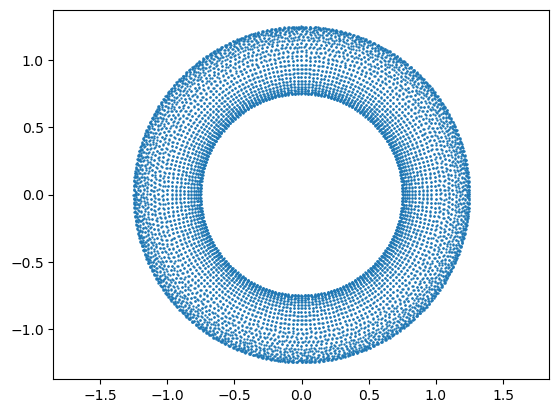

In [52]:
plt.scatter(*v_torus[:,:2].T, s=0.5)
plt.axis('equal')

### Mean and Gaussian curvature convergence tests

### Laplace and gradient operator convergence tests

### Metric tensor and 2nd fundamental form convergence tests